Device: cpu

===== FOLD 1 =====


100%|██████████| 3849/3849 [18:14<00:00,  3.52it/s]


Fold 1 Epoch 1: Train Acc 0.8983 | Val Acc 0.9316


100%|██████████| 3849/3849 [06:03<00:00, 10.59it/s]


Fold 1 Epoch 2: Train Acc 0.9594 | Val Acc 0.9679


...

Fold 5 Epoch 3: Train Acc 0.9704 | Val Acc 0.9817


100%|██████████| 3849/3849 [05:04<00:00, 12.66it/s]


Fold 5 Epoch 4: Train Acc 0.9768 | Val Acc 0.9805


100%|██████████| 3849/3849 [04:59<00:00, 12.83it/s]


Fold 5 Epoch 5: Train Acc 0.9795 | Val Acc 0.9854

===== FINAL RESULTS =====
Accuracy  : 0.9852
Precision : 0.9834
Recall    : 0.9855
F1 Score  : 0.9844


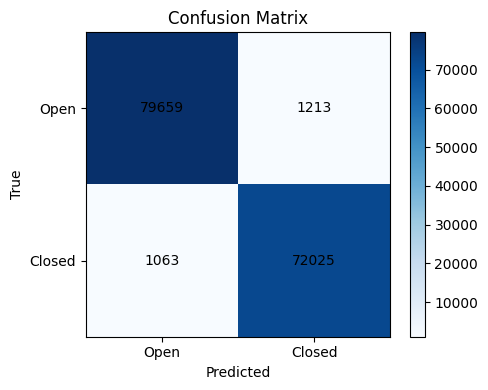

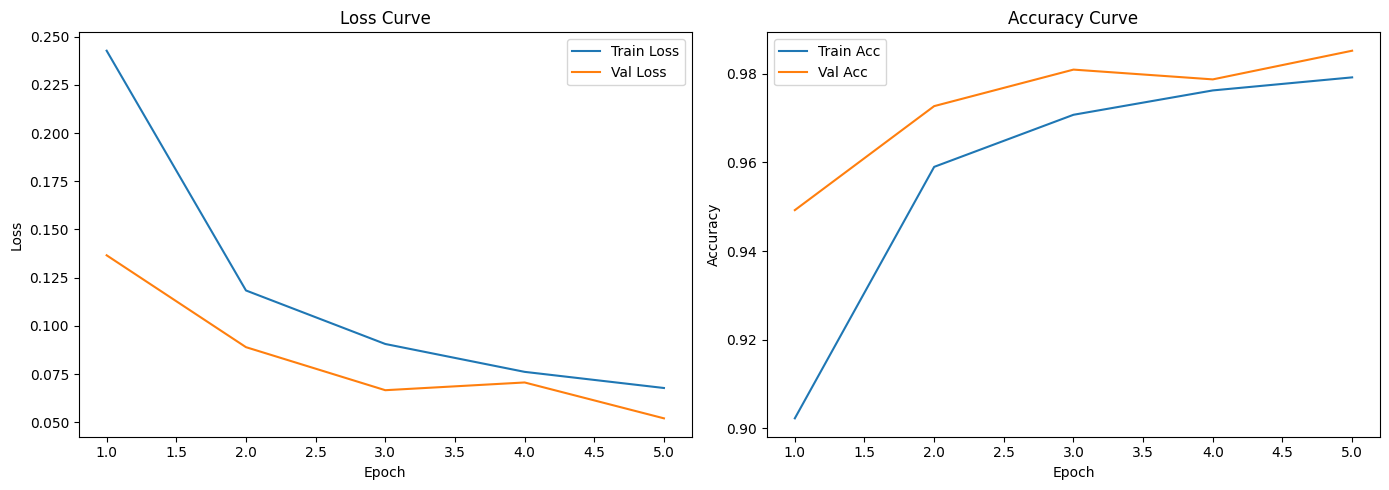

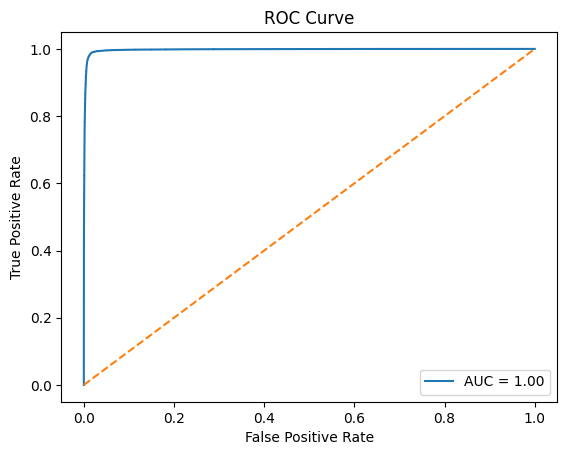

✅ Best model saved at: /kaggle/working/best_eye_cnn.pth


In [1]:
# =========================
# IMPORTS
# =========================
import os, cv2, dlib
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_curve, auc, accuracy_score
)
from sklearn.model_selection import KFold
from scipy.spatial import distance as dist
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================
# DATASET
# =========================
class EyeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.images, self.labels = [], []
        self.transform = transform

        for label, cls in enumerate(["open", "closed"]):
            for img in os.listdir(os.path.join(root_dir, cls)):
                if img.lower().endswith((".jpg", ".png", ".jpeg")):
                    self.images.append(os.path.join(root_dir, cls, img))
                    self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = cv2.imread(self.images[idx], cv2.IMREAD_GRAYSCALE)
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# =========================
# CNN MODEL
# =========================
class EyeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 16, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 2)
        )

    def forward(self, x):
        return self.model(x)

# =========================
# TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# =========================
# EAR SETUP
# =========================
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(
    "/kaggle/input/datasets/humashasaba/shape-predictor-68-face-landmarks-dat/shape_predictor_68_face_landmarks.dat"
)

def eye_aspect_ratio(eye):
    A = dist.euclidean(eye[1], eye[5])
    B = dist.euclidean(eye[2], eye[4])
    C = dist.euclidean(eye[0], eye[3])
    return (A + B) / (2.0 * C)

def compute_ear(img_tensor):
    img = (img_tensor.squeeze().cpu().numpy() * 255).astype("uint8")
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    rects = detector(img, 1)

    if len(rects) > 0:
        shape = predictor(img, rects[0])
        pts = np.array([[p.x, p.y] for p in shape.parts()])
        return (eye_aspect_ratio(pts[42:48]) +
                eye_aspect_ratio(pts[36:42])) / 2.0
    return None

LOW_EAR = 0.20
HIGH_EAR = 0.30

# =========================
# DATA
# =========================
DATASET_PATH = "/kaggle/input/datasets/humashasaba/eye-dataset/Image"
full_dataset = EyeDataset(DATASET_PATH)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_acc = 0.0
model_path = "/kaggle/working/best_eye_cnn.pth"

all_true, all_pred, all_probs = [], [], []
fold_accuracies = []

all_train_loss, all_val_loss = [], []
all_train_acc, all_val_acc = [], []

# =========================
# TRAINING LOOP
# =========================
for fold, (train_idx, test_idx) in enumerate(kf.split(full_dataset)):
    print(f"\n===== FOLD {fold+1} =====")

    train_set = Subset(EyeDataset(DATASET_PATH, train_transform), train_idx)
    test_set  = Subset(EyeDataset(DATASET_PATH, test_transform), test_idx)

    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    test_loader  = DataLoader(test_set, batch_size=32, shuffle=False)

    model = EyeCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    fold_train_loss, fold_val_loss = [], []
    fold_train_acc, fold_val_acc = [], []

    for epoch in range(5):
        # TRAIN
        model.train()
        running_loss, correct, total = 0, 0, 0

        for imgs, labels in tqdm(train_loader):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # VALIDATION
        model.eval()
        running_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                running_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = running_loss / len(test_loader)
        val_acc = correct / total

        fold_train_loss.append(train_loss)
        fold_train_acc.append(train_acc)
        fold_val_loss.append(val_loss)
        fold_val_acc.append(val_acc)

        print(f"Fold {fold+1} Epoch {epoch+1}: "
              f"Train Acc {train_acc:.4f} | Val Acc {val_acc:.4f}")

    all_train_loss.append(fold_train_loss)
    all_val_loss.append(fold_val_loss)
    all_train_acc.append(fold_train_acc)
    all_val_acc.append(fold_val_acc)

    # =========================
    # FINAL TEST (HYBRID)
    # =========================
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            for i in range(len(imgs)):
                ear = compute_ear(imgs[i])
                final_pred = preds[i]

                if ear is not None:
                    if ear < LOW_EAR:
                        final_pred = 1
                    elif ear > HIGH_EAR:
                        final_pred = 0

                y_true.append(labels[i].item())
                y_pred.append(final_pred)
                y_prob.append(probs[i][1].item())

    acc = accuracy_score(y_true, y_pred)
    fold_accuracies.append(acc)

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), model_path)
        print("✅ Best model saved")

    all_true.extend(y_true)
    all_pred.extend(y_pred)
    all_probs.extend(y_prob)

# =========================
# METRICS
# =========================
print("\n===== FINAL RESULTS =====")
print(f"Accuracy  : {np.mean(fold_accuracies):.4f}")
print(f"Precision : {precision_score(all_true, all_pred):.4f}")
print(f"Recall    : {recall_score(all_true, all_pred):.4f}")
print(f"F1 Score  : {f1_score(all_true, all_pred):.4f}")

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(all_true, all_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
classes = ["Open", "Closed"]
plt.xticks(range(2), classes)
plt.yticks(range(2), classes)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# =========================
# ACCURACY & LOSS CURVES
# =========================
avg_train_loss = np.mean(all_train_loss, axis=0)
avg_val_loss   = np.mean(all_val_loss, axis=0)
avg_train_acc  = np.mean(all_train_acc, axis=0)
avg_val_acc    = np.mean(all_val_acc, axis=0)

epochs = range(1, len(avg_train_loss) + 1)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs, avg_train_loss, label="Train Loss")
plt.plot(epochs, avg_val_loss, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, avg_train_acc, label="Train Acc")
plt.plot(epochs, avg_val_acc, label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# =========================
# ROC CURVE
# =========================
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], '--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("✅ Best model saved at:", model_path)